In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Path containing participant files

data_dir = Path(
    "/Users/sm6511/Desktop/Prediction-Accomodation-Exp/data/Study6.0Pilot/raw"
)

# Columns to extract

rating_cols = [
    "obvious_slider.response",
    "salient_slider.response",
    "good_slider.response",
    "plausible_slider.response"
]

keep_cols = [
    "explanationCategory",
    *rating_cols
]

# Load all participants

all_participants = []

for file_path in data_dir.glob("*.csv"):

    try:
        df = pd.read_csv(file_path)

        # Participant ID = portion of filename before first "_"
        # e.g. 137237_pa6fresh_2026... -> 137237
        participant = file_path.name.split("_")[0]

        # Keep only rows corresponding to an explanation category
        df_ratings = (
            df.loc[
                df["explanationCategory"].notna(),
                keep_cols
            ]
            .copy()
        )

        # Add participant ID
        df_ratings.insert(0, "participant", participant)

        all_participants.append(df_ratings)

        print(
            f"{participant}: "
            f"{len(df_ratings)} explanation categories"
        )

    except Exception as e:
        print(f"ERROR: {file_path.name}: {e}")


# Combine participants into one dataframe

df_ratings = pd.concat(
    all_participants,
    ignore_index=True
)

print(df_ratings.head())
print(df_ratings.shape)

df_ratings = df_ratings.rename(columns={
    "obvious_slider.response": "obvious",
    "salient_slider.response": "salient",
    "good_slider.response": "good",
    "plausible_slider.response": "plausible"
})

408272: 10 explanation categories
694949: 10 explanation categories
980805: 10 explanation categories
643877: 10 explanation categories
550159: 10 explanation categories
062382: 10 explanation categories
655884: 10 explanation categories
401354: 10 explanation categories
475358: 10 explanation categories
691259: 10 explanation categories
019455: 10 explanation categories
669469: 10 explanation categories
248622: 10 explanation categories
821812: 10 explanation categories
101013: 10 explanation categories
959269: 10 explanation categories
766676: 10 explanation categories
638089: 10 explanation categories
200994: 10 explanation categories
724436: 10 explanation categories
6a05cc9fdc3fd289748bfa5e: 10 explanation categories
613346: 10 explanation categories
254391: 10 explanation categories
197218: 10 explanation categories
364056: 10 explanation categories
978992: 10 explanation categories
518622: 10 explanation categories
186566: 10 explanation categories
026383: 10 explanation categor

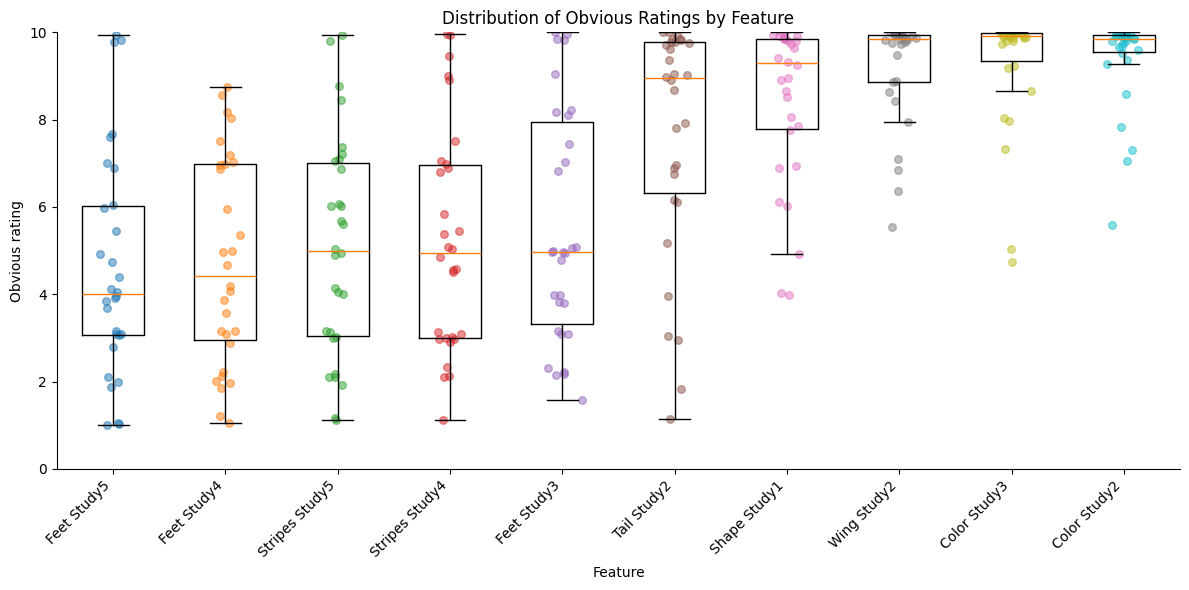

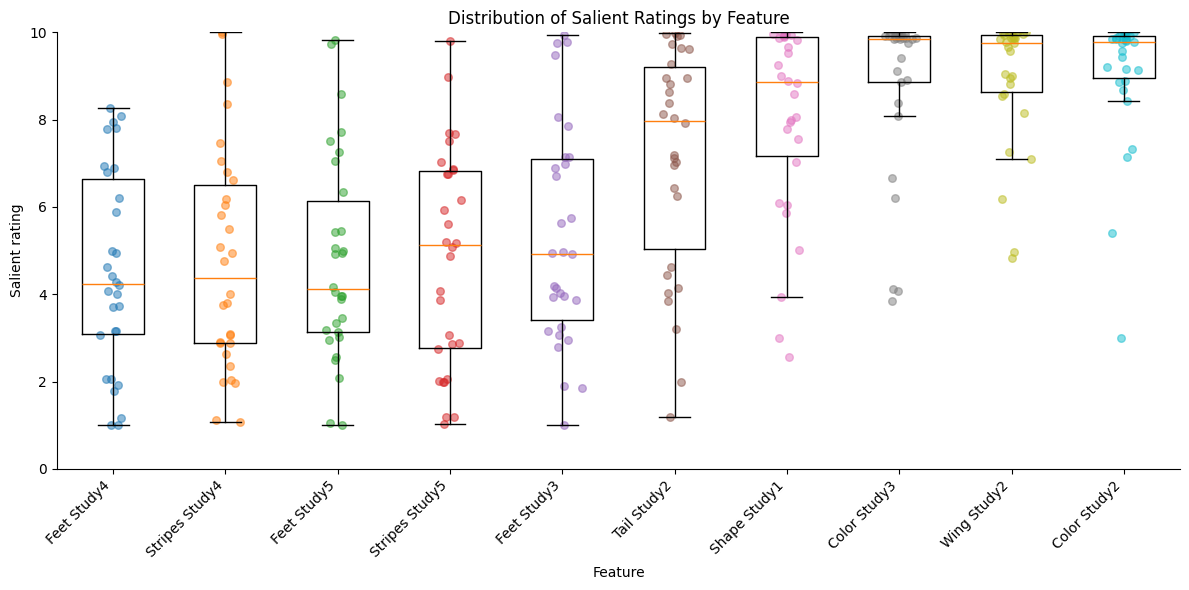

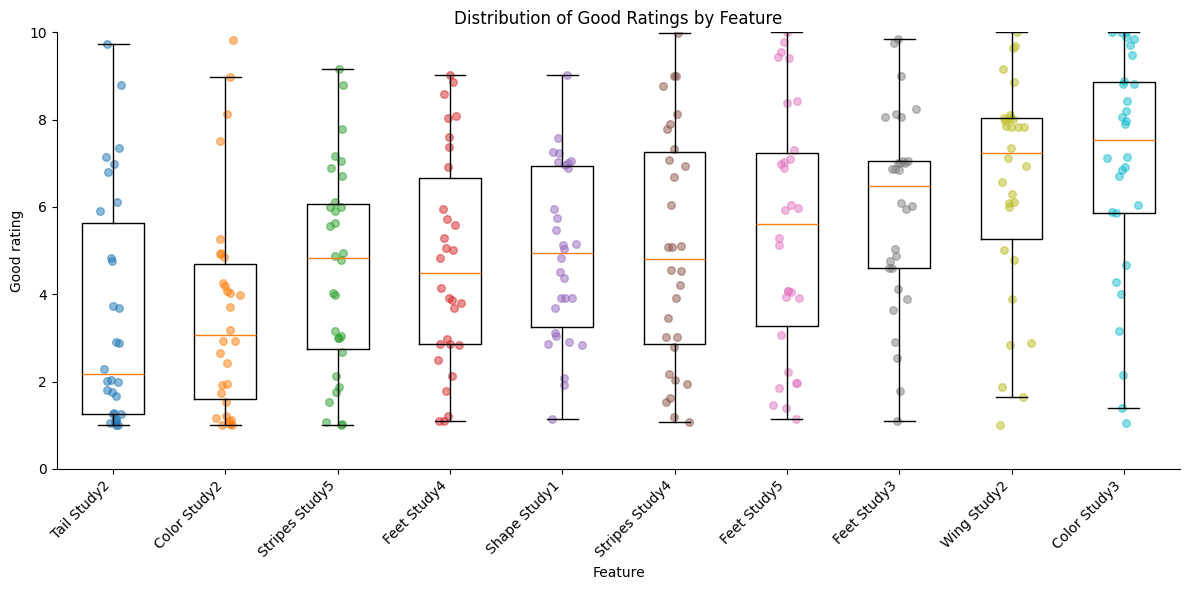

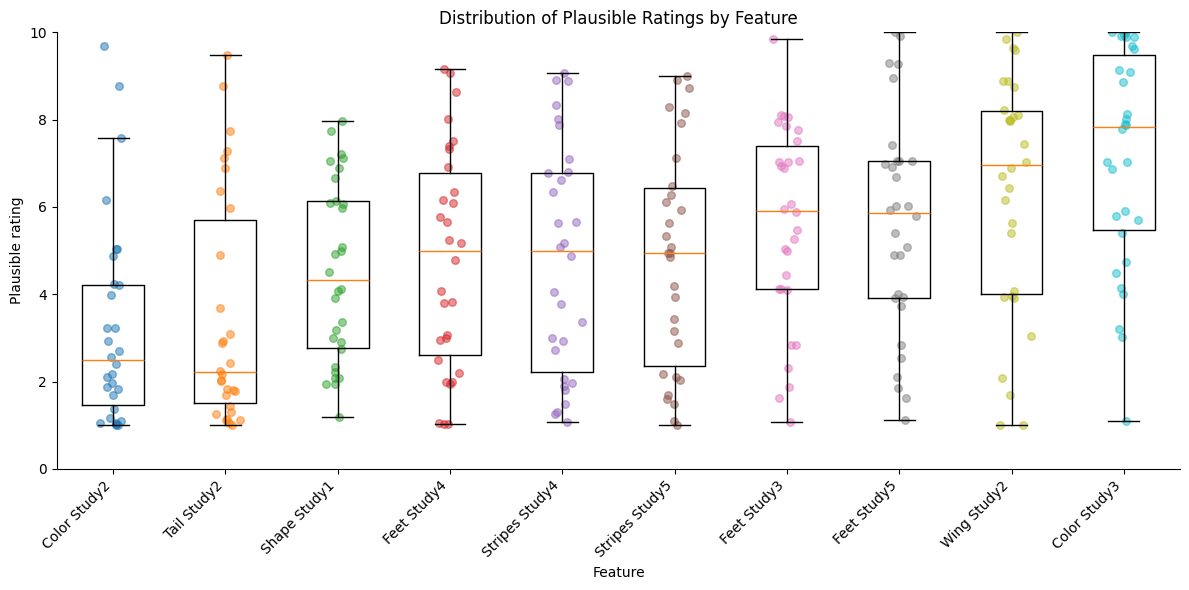

In [3]:
##Rename study name e.g., "Feet_Study3" -> "Feet Study3"

df_plot = df_ratings.copy()
df_plot["feature"] = (
    df_plot["explanationCategory"]
    .str.replace("_", " ", regex=False)
)

rating_cols = [
    "obvious",
    "salient",
    "good",
    "plausible"
]

##Plot each rating

for rating in rating_cols:

    fig, ax = plt.subplots(figsize=(12, 6))

    # Get feature order
    features = (
    df_plot
    .groupby("feature")[rating]
    .mean()
    .sort_values()
    .index
)

    data = [
        df_plot.loc[
            df_plot["feature"] == feature,
            rating
        ].dropna().values
        for feature in features
    ]

    # Boxplots
    ax.boxplot(
        data,
        positions=np.arange(len(features)),
        widths=0.55,
        showfliers=False
    )

    # Individual participant observations
    rng = np.random.default_rng(42)

    for i, values in enumerate(data):

        jitter = rng.normal(
            loc=0,
            scale=0.06,
            size=len(values)
        )

        ax.scatter(
            i + jitter,
            values,
            alpha=0.5,
            s=30
        )

    # Formatting

    ax.set_xticks(np.arange(len(features)))
    ax.set_xticklabels(
        features,
        rotation=45,
        ha="right"
    )

    ax.set_xlabel("Feature")
    ax.set_ylabel(f"{rating.capitalize()} rating")
    ax.set_title(
        f"Distribution of {rating.capitalize()} Ratings by Feature"
    )

    # Assuming sliders run 0–10
    ax.set_ylim(0, 10)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()


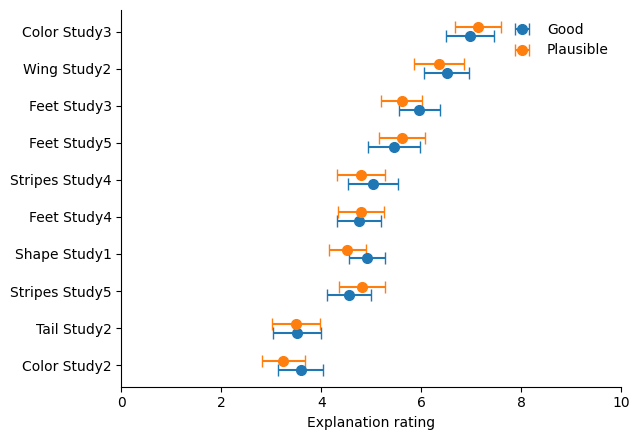

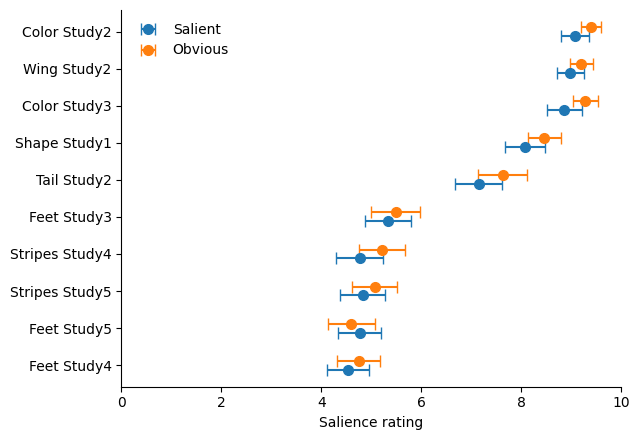

In [4]:

# Two plots:
# 1. Good + Plausible
# 2. Salient + Obvious

rating_pairs = [
    (["good", "plausible"], "Explanation rating"),
    (["salient", "obvious"], "Salience rating")
]

for ratings, xlabel in rating_pairs:

    # Order features by the average of the two ratings
    feature_order = (
        df_plot
        .groupby("feature")[ratings]
        .mean()
        .mean(axis=1)
        .sort_values()
        .index
    )

    fig, ax = plt.subplots(figsize=(6.5, 4.5))

    y = np.arange(len(feature_order))

    # Small vertical offset 
    offsets = [-0.12, 0.12]

    for rating, offset in zip(ratings, offsets):

        summary = (
            df_plot
            .groupby("feature")[rating]
            .agg(["mean", "sem"])
            .loc[feature_order]
        )

        ax.errorbar(
            summary["mean"],
            y + offset,
            xerr=summary["sem"],
            fmt="o",
            markersize=7,
            capsize=4,
            linewidth=1.5,
            label=rating.capitalize()
        )

    ax.set_yticks(y)
    ax.set_yticklabels(feature_order)

    ax.set_xlabel(xlabel)
    ax.set_xlim(0, 10)

    ax.legend(frameon=False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

  explanationCategory  salience  explanation_goodness
0        Color_Study2  9.238065              3.411340
1        Color_Study3  9.074503              7.057184
2         Feet_Study3  5.411952              5.782264
3         Feet_Study4  4.639812              4.773038
4         Feet_Study5  4.688092              5.536561
5        Shape_Study1  8.264307              4.719370
6      Stripes_Study4  4.993076              4.915247
7      Stripes_Study5  4.948828              4.686614
8         Tail_Study2  7.387538              3.500423
9         Wing_Study2  9.091283              6.429076


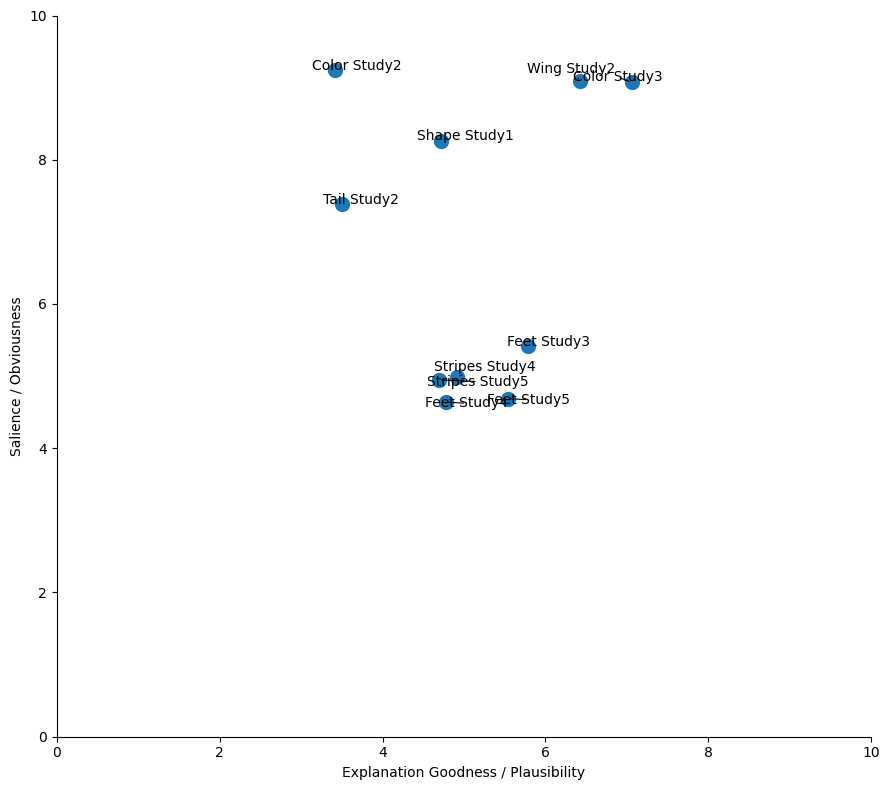

In [5]:
from adjustText import adjust_text
# Create composite scores for each participant × feature
df_plot["salience"] = df_plot[
    ["obvious", "salient"]
].mean(axis=1)

df_plot["explanation_goodness"] = df_plot[
    ["good", "plausible"]
].mean(axis=1)
feature_means = (
    df_plot
    .groupby("explanationCategory", as_index=False)
    .agg(
        salience=("salience", "mean"),
        explanation_goodness=("explanation_goodness", "mean")
    )
)

print(feature_means)


###PLOT
fig, ax = plt.subplots(figsize=(9, 8))

ax.scatter(
    feature_means["explanation_goodness"],
    feature_means["salience"],
    s=100
)

texts = []

for _, row in feature_means.iterrows():

    label = row["explanationCategory"].replace("_", " ")

    texts.append(
        ax.text(
            row["explanation_goodness"],
            row["salience"],
            label
        )
    )

adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(
        arrowstyle="-",
        lw=0.8
    )
)

ax.set_xlabel("Explanation Goodness / Plausibility")
ax.set_ylabel("Salience / Obviousness")

ax.set_xlim(0, 10)
ax.set_ylim(0, 10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


In [7]:
df_plot.to_csv(
    "/Users/sm6511/Desktop/Prediction-Accomodation-Exp/data/Combined/Study6.0PilotRatings.csv",
    index=False
)

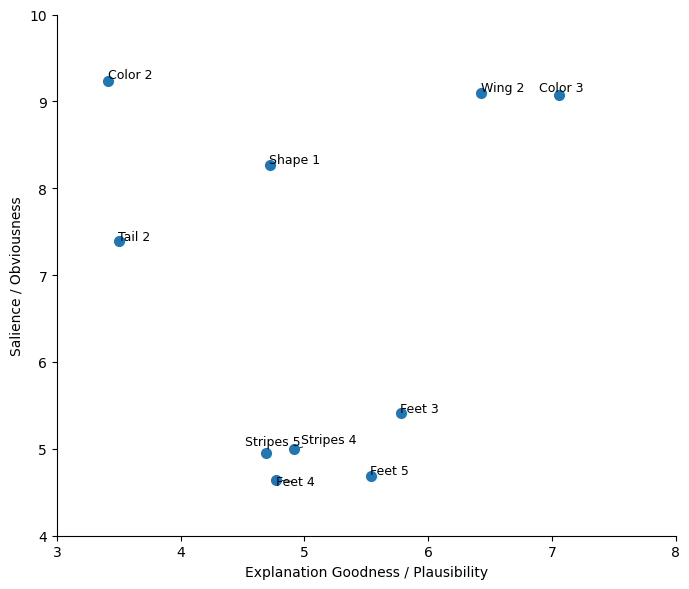

In [6]:
#get SEM and mean

feature_summary = (
    df_plot
    .groupby("explanationCategory")
    .agg(
        salience_mean=("salience", "mean"),
        salience_sem=("salience", "sem"),
        goodness_mean=("explanation_goodness", "mean"),
        goodness_sem=("explanation_goodness", "sem")
    )
    .reset_index()
)
###PLOT

fig, ax = plt.subplots(figsize=(7, 6))

ax.errorbar(
    feature_summary["goodness_mean"],
    feature_summary["salience_mean"],

    #xerr=feature_summary["goodness_sem"],
    #yerr=feature_summary["salience_sem"],

    fmt="o",
    markersize=7,
    capsize=3,
    linewidth=1.2,
    linestyle="none"
)

# Labels
texts = []

for _, row in feature_summary.iterrows():

    label = (
    row["explanationCategory"]
    .replace("_Study", " ")
    .replace("_", " ")
)

    texts.append(
        ax.text(
            row["goodness_mean"],
            row["salience_mean"],
            label,
            fontsize=9
        )
    )

adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(
        arrowstyle="-",
        lw=0.6
    )
)

ax.set_xlabel("Explanation Goodness / Plausibility")
ax.set_ylabel("Salience / Obviousness")

ax.set_xlim(3, 8)
ax.set_ylim(4, 10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [8]:
target_feature = "feet"
df_repeat = df_ratings[
    df_ratings["explanationCategory"]
    .str.lower()
    .str.startswith(target_feature.lower())
].copy()
print(df_repeat.head(20))

   participant explanationCategory   obvious   salient      good  plausible
0       408272         Feet_Study3  9.055558  6.899527  7.013005   5.878253
5       408272         Feet_Study4  5.348704  3.154847  3.684401   6.332152
6       408272         Feet_Study5  3.911352  3.192676  1.150122   1.112297
10      694949         Feet_Study4  2.211426  2.050293  3.910645   7.331055
15      694949         Feet_Study5  3.844727  4.914062  4.071777   5.932129
18      694949         Feet_Study3  2.167480  1.000000  4.760254   2.321289
21      980805         Feet_Study4  2.131148  1.934426  2.967213   3.065574
22      980805         Feet_Study5  1.983607  2.081967  6.901639   7.049180
28      980805         Feet_Study3  3.803279  3.950820  6.852459   6.901639
30      643877         Feet_Study5  1.022727  3.454545  7.295455   6.681818
31      643877         Feet_Study3  8.227273  5.750000  8.136364   5.272727
34      643877         Feet_Study4  6.954545  6.204545  7.613636   5.250000
43      5501

In [9]:
df_repeat["occurrence"] = (
    df_repeat
    .groupby("participant")
    .cumcount() + 1
)

# Composite ratings
df_repeat["salience"] = (
    df_repeat[["obvious", "salient"]]
    .mean(axis=1)
)

df_repeat["explanation_goodness"] = (
    df_repeat[["good", "plausible"]]
    .mean(axis=1)
)

print(
    df_repeat[
        [
            "participant",
            "explanationCategory",
            "occurrence",
            "salience",
            "explanation_goodness"
        ]
    ].head(20)
)

   participant explanationCategory  occurrence  salience  explanation_goodness
0       408272         Feet_Study3           1  7.977543              6.445629
5       408272         Feet_Study4           2  4.251776              5.008276
6       408272         Feet_Study5           3  3.552014              1.131210
10      694949         Feet_Study4           1  2.130859              5.620850
15      694949         Feet_Study5           2  4.379395              5.001953
18      694949         Feet_Study3           3  1.583740              3.540771
21      980805         Feet_Study4           1  2.032787              3.016393
22      980805         Feet_Study5           2  2.032787              6.975410
28      980805         Feet_Study3           3  3.877049              6.877049
30      643877         Feet_Study5           1  2.238636              6.988636
31      643877         Feet_Study3           2  6.988636              6.704545
34      643877         Feet_Study4           3  6.57

In [10]:


def plot_repeated_feature(df_repeat, rating, ylabel):

    fig, ax = plt.subplots(figsize=(6, 5))


    for participant, participant_df in df_repeat.groupby("participant"):

        participant_df = participant_df.sort_values("occurrence")

        ax.plot(
            participant_df["occurrence"],
            participant_df[rating],
            marker="o",
            markersize=3,
            linewidth=0.7,
            alpha=0.15
        )

    summary = (
        df_repeat
        .groupby("occurrence")[rating]
        .agg(["mean", "sem"])
        .reset_index()
    )

    ax.errorbar(
        summary["occurrence"],
        summary["mean"],
        yerr=summary["sem"],
        fmt="o-",
        markersize=8,
        linewidth=2,
        capsize=5
    )

    ax.set_xticks(summary["occurrence"])

    ax.set_xticklabels([
        f"{target_feature.capitalize()} {i}"
        for i in summary["occurrence"]
    ])

    ax.set_xlabel("Order presented")
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 10)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

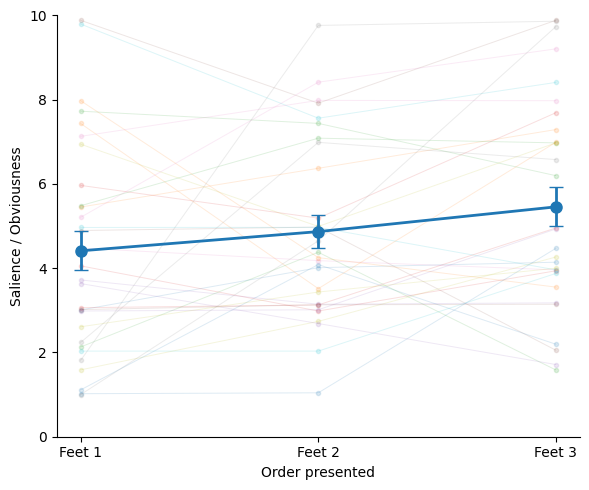

In [11]:
plot_repeated_feature(
    df_repeat,
    "salience",
    "Salience / Obviousness"
)

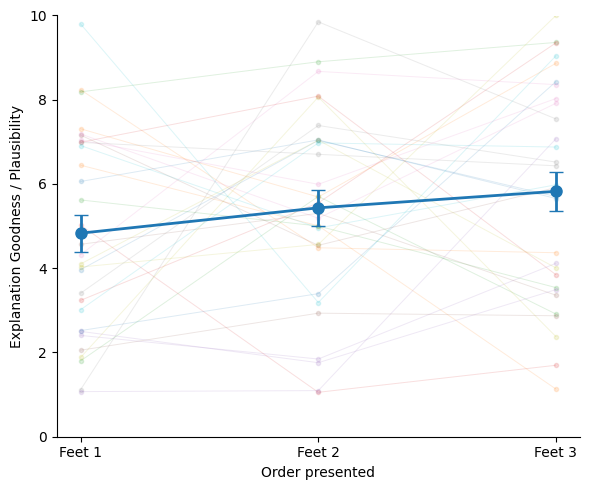

In [12]:
plot_repeated_feature(
    df_repeat,
    "explanation_goodness",
    "Explanation Goodness / Plausibility"
)

   participant  presentation_order explanationCategory   salience  \
0       408272                   1         Feet_Study3   7.977543   
1       408272                   2      Stripes_Study4   2.020099   
2       408272                   3      Stripes_Study5   2.171396   
3       408272                   4        Shape_Study1   8.942088   
4       408272                   5        Color_Study2   9.263594   
5       408272                   6         Feet_Study4   4.251776   
6       408272                   7         Feet_Study5   3.552014   
7       408272                   8         Wing_Study2   9.774240   
8       408272                   9        Color_Study3   9.887711   
9       408272                  10         Tail_Study2   8.091018   
10      694949                   1         Feet_Study4   2.130859   
11      694949                   2        Color_Study3  10.000000   
12      694949                   3         Wing_Study2  10.000000   
13      694949                   4

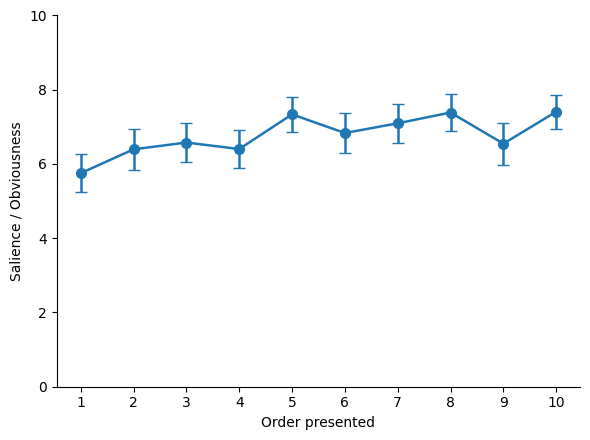

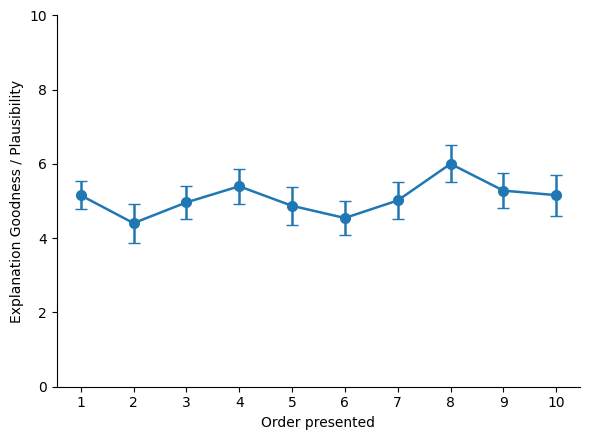

In [13]:
df_order = df_ratings.copy()

df_order["presentation_order"] = (
    df_order
    .groupby("participant")
    .cumcount() + 1
)

# Composite scores
df_order["salience"] = (
    df_order[["obvious", "salient"]]
    .mean(axis=1)
)

df_order["explanation_goodness"] = (
    df_order[["good", "plausible"]]
    .mean(axis=1)
)

# Quick sanity check
print(
    df_order[
        [
            "participant",
            "presentation_order",
            "explanationCategory",
            "salience",
            "explanation_goodness"
        ]
    ].head(20)
)
ratings_to_plot = [
    ("salience", "Salience / Obviousness"),
    ("explanation_goodness", "Explanation Goodness / Plausibility")
]

for rating, ylabel in ratings_to_plot:

    summary = (
        df_order
        .groupby("presentation_order")[rating]
        .agg(["mean", "sem"])
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(6, 4.5))

    ax.errorbar(
        summary["presentation_order"],
        summary["mean"],
        yerr=summary["sem"],
        fmt="o-",
        markersize=7,
        capsize=4,
        linewidth=1.8
    )

    ax.set_xticks(summary["presentation_order"])
    ax.set_xlabel("Order presented")
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 10)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()